<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/PHDS_thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **importing the dataset of all the 28 countries**

In [118]:
import pandas as pd
import gdown
file_id = '1ejOAzi_5AnQElvjk7tJ-ImIfwxG1x4Fr'
output_filename = 'All.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_filename, quiet=False)
df = pd.read_csv(output_filename, encoding='latin1')
df.shape
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1ejOAzi_5AnQElvjk7tJ-ImIfwxG1x4Fr
From (redirected): https://drive.google.com/uc?id=1ejOAzi_5AnQElvjk7tJ-ImIfwxG1x4Fr&confirm=t&uuid=b6150b38-3977-4653-9a35-df257fa631e6
To: /content/All.csv
100%|██████████| 131M/131M [00:01<00:00, 69.4MB/s]
/tmp/ipykernel_1371/2464451880.py:6: DtypeWarning:

Columns (10,24,28,29,40,42) have mixed types. Specify dtype option on import or set low_memory=False.



,caseid,v000,v001,v005,v007,v012,v021,v024,v025,v106,v130,v157,v158,v159,v169a,v171a,v190,v228,v312,v394,v467a,v467b,v467c,v467d,v481,v501,v525,v717,v751,v754bp,v754cp,v754dp,v754jp,v754wp,v756,v761,v762,v763a,v763b,v763c,v766b,v781,v783
0,1 1 01,AO8,1,771031,2023,21,1,moxico,urban,secondary,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,no,NaN,not a big problem,not a big problem,not a big problem,no,living with partner,19,not working,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,0,no,NaN
1,1 2 02,AO8,1,771031,2023,20,1,moxico,urban,primary,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,no,NaN,not a big problem,not a big problem,not a big problem,no,living with partner,19,not working,no,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,no,no,no,1,no,NaN
2,1 3 02,AO8,1,771031,2023,21,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,yes,NaN,not a big problem,big problem,not a big problem,no,living with partner,15,not working,yes,NaN,yes,yes,no,no,yes,no,NaN,no,no,no,1,yes,NaN
3,1 4 02,AO8,1,771031,2023,19,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,yes,NaN,not a big problem,big problem,not a big problem,no,living with partner,11,not working,no,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,no,no,no,1,no,NaN
4,1 7 01,AO8,1,771031,2023,32,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorest,no,not using,no,NaN,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,15,not working,no,NaN,NaN,NaN,NaN,NaN,NaN,no,NaN,no,no,no,1,no,NaN


# **Data Cleaning**

In [119]:
# Identify rows where Maternal_age > 49
over_age_mask = df['v012'] > 49

# Report the number of rows to be removed by country
print("Number of rows to be removed (v012 > 49) by v000:")
print(df[over_age_mask].groupby('v000').size().sort_values(ascending=False))

# Remove the rows from the dataframe
initial_count = len(df)
df = df[~over_age_mask]
final_count = len(df)

print(f"\nTotal rows removed: {initial_count - final_count}")
print(f"New dataset shape: {df.shape}")

Number of rows to be removed (v012 > 49) by v000:
v000
ML8    3152
GA7    1536
CM7    1150
dtype: int64

Total rows removed: 5838
New dataset shape: (459758, 43)


## **Total Number of samples in each country and year of Survey**

In [120]:
country_mapping = {
    'AO8': 'Angola',
    'BF8': 'Burkina Faso',
    'BJ7': 'Benin',
    'BU7': 'Burundi',
    'CD8': 'DR Congo',
    'CI8': 'Côte d’Ivoire',
    'CM7': 'Cameroon',
    'ET7': 'Ethiopia',
    'GA7': 'Gabon',
    'GH8': 'Ghana',
    'GM7': 'Gambia',
    'GN7': 'Guinea',
    'KE8': 'Kenya',
    'LB7': 'Liberia',
    'LS8': 'Lesotho',
    'MD7': 'Madagascar',
    'ML8': 'Mali',
    'MR7': 'Mauritania',
    'MW8': 'Malawi',
    'MZ8': 'Mozambique',
    'NG8': 'Nigeria',
    'RW7': 'Rwanda',
    'SL7': 'Sierra Leone',
    'SN8': 'Senegal',
    'TZ8': 'Tanzania',
    'UG7': 'Uganda',
    'ZA7': 'South Africa',
    'ZM8': 'Zambia'
}

# Rename the categories in the v000 column
df['v000'] = df['v000'].map(country_mapping).fillna(df['v000'])

# Display the unique values to confirm
print(df['v000'].unique())

['Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon' 'Côte d’Ivoire'
 'DR Congo' 'Ethiopia' 'Gabon' 'Gambia' 'Ghana' 'Guinea' 'Kenya' 'Lesotho'
 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mozambique'
 'Nigeria' 'Rwanda' 'Senegal' 'Sierra Leone' 'South Africa' 'Tanzania'
 'Uganda' 'Zambia']


In [121]:
df.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v024',
       'v025', 'v106', 'v130', 'v157', 'v158', 'v159', 'v169a', 'v171a',
       'v190', 'v228', 'v312', 'v394', 'v467a', 'v467b', 'v467c', 'v467d',
       'v481', 'v501', 'v525', 'v717', 'v751', 'v754bp', 'v754cp', 'v754dp',
       'v754jp', 'v754wp', 'v756', 'v761', 'v762', 'v763a', 'v763b', 'v763c',
       'v766b', 'v781', 'v783'],
      dtype='object')

### removing the who have no sexual intercourse history

In [122]:
# Show the count of 'not had sex' in v525 by country
print("Count of respondents who have 'not had sex' by country:")
never_had_sex_counts = df[df['v525'] == 'not had sex'].groupby('v000').size()
print(never_had_sex_counts)

# Remove rows where age_first_sex is 'not had sex'
initial_shape = df.shape
df = df[df['v525'] != 'not had sex']
new_shape = df.shape

print(f"\nRows removed: {initial_shape[0] - new_shape[0]}")
print(f"New dataset shape: {new_shape}")

Count of respondents who have 'not had sex' by country:
v000
Angola           1882
Benin            1953
Burkina Faso     2523
Burundi          5256
Cameroon         2058
Côte d’Ivoire    1663
DR Congo         4211
Ethiopia         3721
Gabon            1086
Gambia           3041
Ghana            2017
Guinea           1712
Kenya            5258
Lesotho           727
Liberia           490
Madagascar       2046
Malawi           2563
Mali             2623
Mauritania         34
Mozambique       1222
Nigeria          7454
Rwanda           4044
Senegal          4450
Sierra Leone     1609
South Africa     1038
Tanzania         2527
Uganda           2671
Zambia           1707
dtype: int64

Rows removed: 71586
New dataset shape: (388172, 43)


In [123]:
# Reshape the data from wide to long format
tabulation_table = pd.crosstab(df['v000'], df['v007'])
reshaped_df = tabulation_table.stack().reset_index()
reshaped_df.columns = ['Country', 'Year of Survey', 'Total Survey']
reshaped_df = reshaped_df[reshaped_df['Total Survey'] > 0].reset_index(drop=True)

# Group any number of consecutive years for the same country
def merge_consecutive_years(group):
    # The group name (Country) is available via the name attribute when using apply
    country_name = group.name
    group = group.sort_values('Year of Survey')
    merged = []
    if group.empty:
        return pd.DataFrame(merged)

    i = 0
    while i < len(group):
        current_years = [str(group.iloc[i]['Year of Survey'])]
        total_survey = group.iloc[i]['Total Survey']

        j = i + 1
        while j < len(group) and group.iloc[j]['Year of Survey'] == group.iloc[j-1]['Year of Survey'] + 1:
            current_years.append(str(group.iloc[j]['Year of Survey']))
            total_survey += group.iloc[j]['Total Survey']
            j += 1

        merged.append({
            'Country': country_name,
            'Year of Survey': '/'.join(current_years),
            'Total Survey': total_survey
        })
        i = j
    return pd.DataFrame(merged)

final_df = reshaped_df.groupby('Country', group_keys=False).apply(merge_consecutive_years, include_groups=False).reset_index(drop=True)
print(final_df)

# Save the final dataframe as a csv
final_df.to_csv('survey_summary.csv', index=False)
print("\nFile saved as survey_summary.csv")

          Country  Year of Survey  Total Survey
0          Angola       2023/2024         12835
1           Benin       2017/2018         13975
2    Burkina Faso            2021         15136
3         Burundi       2016/2017         12013
4        Cameroon       2018/2019         11469
5   Côte d’Ivoire            2021         13214
6        DR Congo       2023/2024         23372
7        Ethiopia            2008         11962
8           Gabon  2019/2020/2021          8421
9          Gambia       2019/2020          8824
10          Ghana       2022/2023         12997
11         Guinea            2018          9162
12          Kenya            2022         26898
13        Lesotho       2023/2024          5686
14        Liberia       2019/2020          7575
15     Madagascar            2021         16823
16         Malawi            2024         19024
17           Mali       2023/2024         14579
18     Mauritania  2019/2020/2021         15680
19     Mozambique       2022/2023       

## Missing Values management

### the missing values more than 20% were removed

In [124]:
# Calculate the percentage of missing values for each column
missing_percent = (df.isnull().sum() / len(df)) * 100

# Identify columns to remove (missing values > 20%)
cols_to_remove = missing_percent[missing_percent > 20].index.tolist()

print(f"Columns with >20% missing values: {cols_to_remove}")

# Drop these columns
df = df.drop(columns=cols_to_remove)

print(f"\nRemoved {len(cols_to_remove)} columns.")
print(f"New dataframe shape: {df.shape}")

# Show remaining missing values if any
remaining_missing = (df.isnull().sum() / len(df)) * 100
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("\nRemaining missing values (<= 20%):")
print(remaining_missing if not remaining_missing.empty else "No missing values remaining.")

Columns with >20% missing values: ['v467a', 'v751', 'v754bp', 'v754cp', 'v754dp', 'v754jp', 'v754wp', 'v756', 'v762', 'v783']

Removed 10 columns.
New dataframe shape: (388172, 33)

Remaining missing values (<= 20%):
v761     16.916728
v130      9.244098
v481      8.618860
v766b     7.335666
v763c     6.958771
v763b     6.958771
v467b     4.985676
v467c     4.985676
v467d     4.985676
v394      4.828272
v763a     4.387746
v781      3.296219
v525      1.093587
v190      0.144266
v717      0.008759
v157      0.002061
dtype: float64


In [125]:
df.head()

,caseid,v000,v001,v005,v007,v012,v021,v024,v025,v106,v130,v157,v158,v159,v169a,v171a,v190,v228,v312,v394,v467b,v467c,v467d,v481,v501,v525,v717,v761,v763a,v763b,v763c,v766b,v781
0,1 1 01,Angola,1,771031,2023,21,1,moxico,urban,secondary,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,not a big problem,not a big problem,no,living with partner,19,not working,NaN,no,no,no,0,no
1,1 2 02,Angola,1,771031,2023,20,1,moxico,urban,primary,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,not a big problem,not a big problem,no,living with partner,19,not working,no,no,no,no,1,no
2,1 3 02,Angola,1,771031,2023,21,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,big problem,not a big problem,no,living with partner,15,not working,no,no,no,no,1,yes
3,1 4 02,Angola,1,771031,2023,19,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,big problem,not a big problem,no,living with partner,11,not working,no,no,no,no,1,no
4,1 7 01,Angola,1,771031,2023,32,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,15,not working,no,no,no,no,1,no


In [126]:
df.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v024',
       'v025', 'v106', 'v130', 'v157', 'v158', 'v159', 'v169a', 'v171a',
       'v190', 'v228', 'v312', 'v394', 'v467b', 'v467c', 'v467d', 'v481',
       'v501', 'v525', 'v717', 'v761', 'v763a', 'v763b', 'v763c', 'v766b',
       'v781'],
      dtype='object')

In [127]:
df = df.rename(columns={
    "caseid": "case_id",
    "v000": "country",
    "v001": "cluster_cluster",
    "v005": "sample_weight",
    "v007": "survey_year",
    "v012": "Maternal_age",
    "v021": "psu",
    "v024": "region",
    "v025": "residence",
    "v106": "education_level",
    "v130": "religion",
    "v157": "reads_newspaper",
    "v158": "listens_radio",
    "v159": "watches_tv",
    "v169a": "owns_mobile_phone",
    "v171a": "uses_internet",
    "v190": "wealth_index",
    "v228": "ever_terminated_pregnancy",
    "v467d": "distance_to_health_facility",
    "v312": "contraceptive_method",
    "v394": "visited_HF-in last12_months",
    "v481": "Health_insurance_coverage",
    "v501": "marital_status",
    "v525": "age_first_sex",
    "v717": "Occupation_status",
    "v763a": "had_any_STI_in12months",
    "v763b": "genital_ulcer_in12months",
    "v763c": "genital_discharge_in12months",
    "v766b": "number_sexual_partner_12months",
    "v781": "ever_tested_for_HIV"
})

In [128]:
df.head()

,case_id,country,cluster_cluster,sample_weight,survey_year,Maternal_age,psu,region,residence,education_level,religion,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,contraceptive_method,visited_HF-in last12_months,v467b,v467c,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,v761,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV
0,1 1 01,Angola,1,771031,2023,21,1,moxico,urban,secondary,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,not a big problem,not a big problem,no,living with partner,19,not working,NaN,no,no,no,0,no
1,1 2 02,Angola,1,771031,2023,20,1,moxico,urban,primary,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,not a big problem,not a big problem,no,living with partner,19,not working,no,no,no,no,1,no
2,1 3 02,Angola,1,771031,2023,21,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,big problem,not a big problem,no,living with partner,15,not working,no,no,no,no,1,yes
3,1 4 02,Angola,1,771031,2023,19,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,big problem,not a big problem,no,living with partner,11,not working,no,no,no,no,1,no
4,1 7 01,Angola,1,771031,2023,32,1,moxico,urban,no education,protestant,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,15,not working,no,no,no,no,1,no


In [129]:
df.columns

Index(['case_id', 'country', 'cluster_cluster', 'sample_weight', 'survey_year',
       'Maternal_age', 'psu', 'region', 'residence', 'education_level',
       'religion', 'reads_newspaper', 'listens_radio', 'watches_tv',
       'owns_mobile_phone', 'uses_internet', 'wealth_index',
       'ever_terminated_pregnancy', 'contraceptive_method',
       'visited_HF-in last12_months', 'v467b', 'v467c',
       'distance_to_health_facility', 'Health_insurance_coverage',
       'marital_status', 'age_first_sex', 'Occupation_status', 'v761',
       'had_any_STI_in12months', 'genital_ulcer_in12months',
       'genital_discharge_in12months', 'number_sexual_partner_12months',
       'ever_tested_for_HIV'],
      dtype='object')

### **Recategorize country based on the geographic region**

In [130]:
region_map = {
    # West Africa
    "Benin": "West Africa",
    "Burkina Faso": "West Africa",
    "Côte d’Ivoire": "West Africa",
    "Gambia": "West Africa",
    "Ghana": "West Africa",
    "Guinea": "West Africa",
    "Liberia": "West Africa",
    "Mali": "West Africa",
    "Mauritania": "West Africa",
    "Nigeria": "West Africa",
    "Senegal": "West Africa",
    "Sierra Leone": "West Africa",

    # East Africa
    "Burundi": "East Africa",
    "Ethiopia": "East Africa",
    "Kenya": "East Africa",
    "Rwanda": "East Africa",
    "Tanzania": "East Africa",
    "Uganda": "East Africa",

    # Central Africa
    "Cameroon": "Central Africa",
    "Gabon": "Central Africa",
    "DR Congo": "Central Africa",

    # Southern Africa
    "Angola": "Southern Africa",
    "Lesotho": "Southern Africa",
    "Madagascar": "Southern Africa",
    "Malawi": "Southern Africa",
    "Mozambique": "Southern Africa",
    "South Africa": "Southern Africa",
    "Zambia": "Southern Africa"
}

# Apply mapping
df['Geographic_region'] = df['country'].map(region_map)


In [131]:
df.columns

Index(['case_id', 'country', 'cluster_cluster', 'sample_weight', 'survey_year',
       'Maternal_age', 'psu', 'region', 'residence', 'education_level',
       'religion', 'reads_newspaper', 'listens_radio', 'watches_tv',
       'owns_mobile_phone', 'uses_internet', 'wealth_index',
       'ever_terminated_pregnancy', 'contraceptive_method',
       'visited_HF-in last12_months', 'v467b', 'v467c',
       'distance_to_health_facility', 'Health_insurance_coverage',
       'marital_status', 'age_first_sex', 'Occupation_status', 'v761',
       'had_any_STI_in12months', 'genital_ulcer_in12months',
       'genital_discharge_in12months', 'number_sexual_partner_12months',
       'ever_tested_for_HIV', 'Geographic_region'],
      dtype='object')

In [132]:
columns_to_keep = [
    'country','Maternal_age', 'residence', 'education_level',
    'reads_newspaper', 'listens_radio', 'watches_tv',
    'owns_mobile_phone', 'uses_internet', 'wealth_index',
    'ever_terminated_pregnancy', 'contraceptive_method',
    'visited_HF-in last12_months', 'distance_to_health_facility',
    'Health_insurance_coverage', 'marital_status', 'age_first_sex',
    'Occupation_status', 'had_any_STI_in12months',
    'genital_ulcer_in12months', 'genital_discharge_in12months',
    'number_sexual_partner_12months', 'ever_tested_for_HIV',
    'Geographic_region'
]

# Filter the dataframe to the selected columns
df = df[columns_to_keep]

# Display the first few rows to confirm
df.head()

,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,contraceptive_method,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,0,no,Southern Africa
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,1,no,Southern Africa
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,15,not working,no,no,no,1,yes,Southern Africa
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,11,not working,no,no,no,1,no,Southern Africa
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,no,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa


### Creating Media exposure feature

In [133]:
media_cols = ['reads_newspaper', 'listens_radio', 'watches_tv']

# Map responses to check for 'at least once a week' exposure
# Standard DHS responses: 'at least once a week' and 'almost every day' count as exposure
def check_exposure(val):
    if pd.isna(val):
        return 0
    if str(val).lower() in ['at least once a week', 'almost every day']:
        return 1
    return 0

# Create individual exposure flags
for col in media_cols:
    df[f'exp_{col}'] = df[col].apply(check_exposure)

# Media exposure = 1 if exposed to at least one form within a week, else 0
df['Media_exposure'] = df[[f'exp_{col}' for col in media_cols]].max(axis=1)

# Drop intermediate calculation columns
df = df.drop(columns=[f'exp_{col}' for col in media_cols])

# Show results as percentages
print("Media Exposure Percentages:")
print(df['Media_exposure'].value_counts(normalize=True) * 100)
df.head()

Media Exposure Percentages:
Media_exposure
0    52.509197
1    47.490803
Name: proportion, dtype: float64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,contraceptive_method,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,0,no,Southern Africa,0
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,1,no,Southern Africa,0
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,15,not working,no,no,no,1,yes,Southern Africa,0
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,11,not working,no,no,no,1,no,Southern Africa,0
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,no,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa,0


In [134]:
df.columns

Index(['country', 'Maternal_age', 'residence', 'education_level',
       'reads_newspaper', 'listens_radio', 'watches_tv', 'owns_mobile_phone',
       'uses_internet', 'wealth_index', 'ever_terminated_pregnancy',
       'contraceptive_method', 'visited_HF-in last12_months',
       'distance_to_health_facility', 'Health_insurance_coverage',
       'marital_status', 'age_first_sex', 'Occupation_status',
       'had_any_STI_in12months', 'genital_ulcer_in12months',
       'genital_discharge_in12months', 'number_sexual_partner_12months',
       'ever_tested_for_HIV', 'Geographic_region', 'Media_exposure'],
      dtype='object')

### processing the outcome variables (self report of STI)

In [135]:
sti_cols = ['had_any_STI_in12months', 'genital_ulcer_in12months', 'genital_discharge_in12months']

for col in sti_cols:
    print(f"--- Frequency distribution for {col} ---")
    counts = df[col].value_counts(dropna=False)
    percents = df[col].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percents})
    display(summary)
    print("\n")

--- Frequency distribution for had_any_STI_in12months ---


,Count,Percentage (%)
had_any_STI_in12months,,
no,344603,88.775852
yes,25945,6.683893
NaN,17032,4.387746
don't know,592,0.152510




--- Frequency distribution for genital_ulcer_in12months ---


,Count,Percentage (%)
genital_ulcer_in12months,,
no,330949,85.258339
yes,28323,7.296508
NaN,27012,6.958771
don't know,1888,0.486382




--- Frequency distribution for genital_discharge_in12months ---


,Count,Percentage (%)
genital_discharge_in12months,,
no,306752,79.024762
yes,52547,13.537040
NaN,27012,6.958771
don't know,1861,0.479427


In [136]:
# Define the STI indicator columns
sti_cols = ['had_any_STI_in12months', 'genital_discharge_in12months', 'genital_ulcer_in12months']

# Create a function to categorize STI status
def categorize_sti(row):
    # Extract values and convert to lowercase for consistent comparison
    vals = [str(row[col]).lower() for col in sti_cols if pd.notna(row[col])]
    if 'yes' in vals:
        return 1
    return 0

# Apply the function to create the dummy coded 'STI' variable
df['STI'] = df.apply(categorize_sti, axis=1)

# Show the results
print("Frequency distribution for the new 'STI' variable (0 = No, 1 = Yes):")
print(df['STI'].value_counts())
print("\nPercentage distribution:")
print(df['STI'].value_counts(normalize=True) * 100)

df.head()

Frequency distribution for the new 'STI' variable (0 = No, 1 = Yes):
STI
0    318841
1     69331
Name: count, dtype: int64

Percentage distribution:
STI
0    82.139103
1    17.860897
Name: proportion, dtype: float64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,contraceptive_method,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,0,no,Southern Africa,0,0
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,1,no,Southern Africa,0,0
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,15,not working,no,no,no,1,yes,Southern Africa,0,0
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,11,not working,no,no,no,1,no,Southern Africa,0,0
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,no,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa,0,0


#### SR STI by country

In [137]:
# Re-attach the country column from the original mapping context if necessary
# Since df was filtered to columns_to_keep, ensure 'country' or its alias is available.
# In cell 7893W3eyTqUP, v000 was renamed to 'country'.

# Calculate the percentage of STI = 1 by country
sti_by_country = df.groupby('country')['STI'].mean() * 100

# Sort for better visualization
sti_by_country = sti_by_country.sort_values(ascending=False).reset_index()
sti_by_country.columns = ['Country', 'STI Percentage (%)']

print("Percentage of reported STI by Country:")
print(sti_by_country)

Percentage of reported STI by Country:
          Country  STI Percentage (%)
0         Liberia           45.201320
1            Mali           42.437753
2          Guinea           33.355163
3           Ghana           26.952374
4   Côte d’Ivoire           25.238384
5          Uganda           23.593306
6        DR Congo           23.515317
7    Sierra Leone           21.439313
8          Angola           21.106350
9         Lesotho           21.016532
10   Burkina Faso           19.985465
11         Malawi           18.587048
12        Senegal           18.536224
13       Cameroon           18.249193
14     Mauritania           17.653061
15     Mozambique           17.598863
16        Nigeria           16.052665
17       Tanzania           13.255284
18         Rwanda           13.182247
19   South Africa           12.734082
20         Gambia           12.296011
21          Gabon           11.138820
22        Burundi           10.613502
23         Zambia            8.910487
24         

### Visualize using barplot

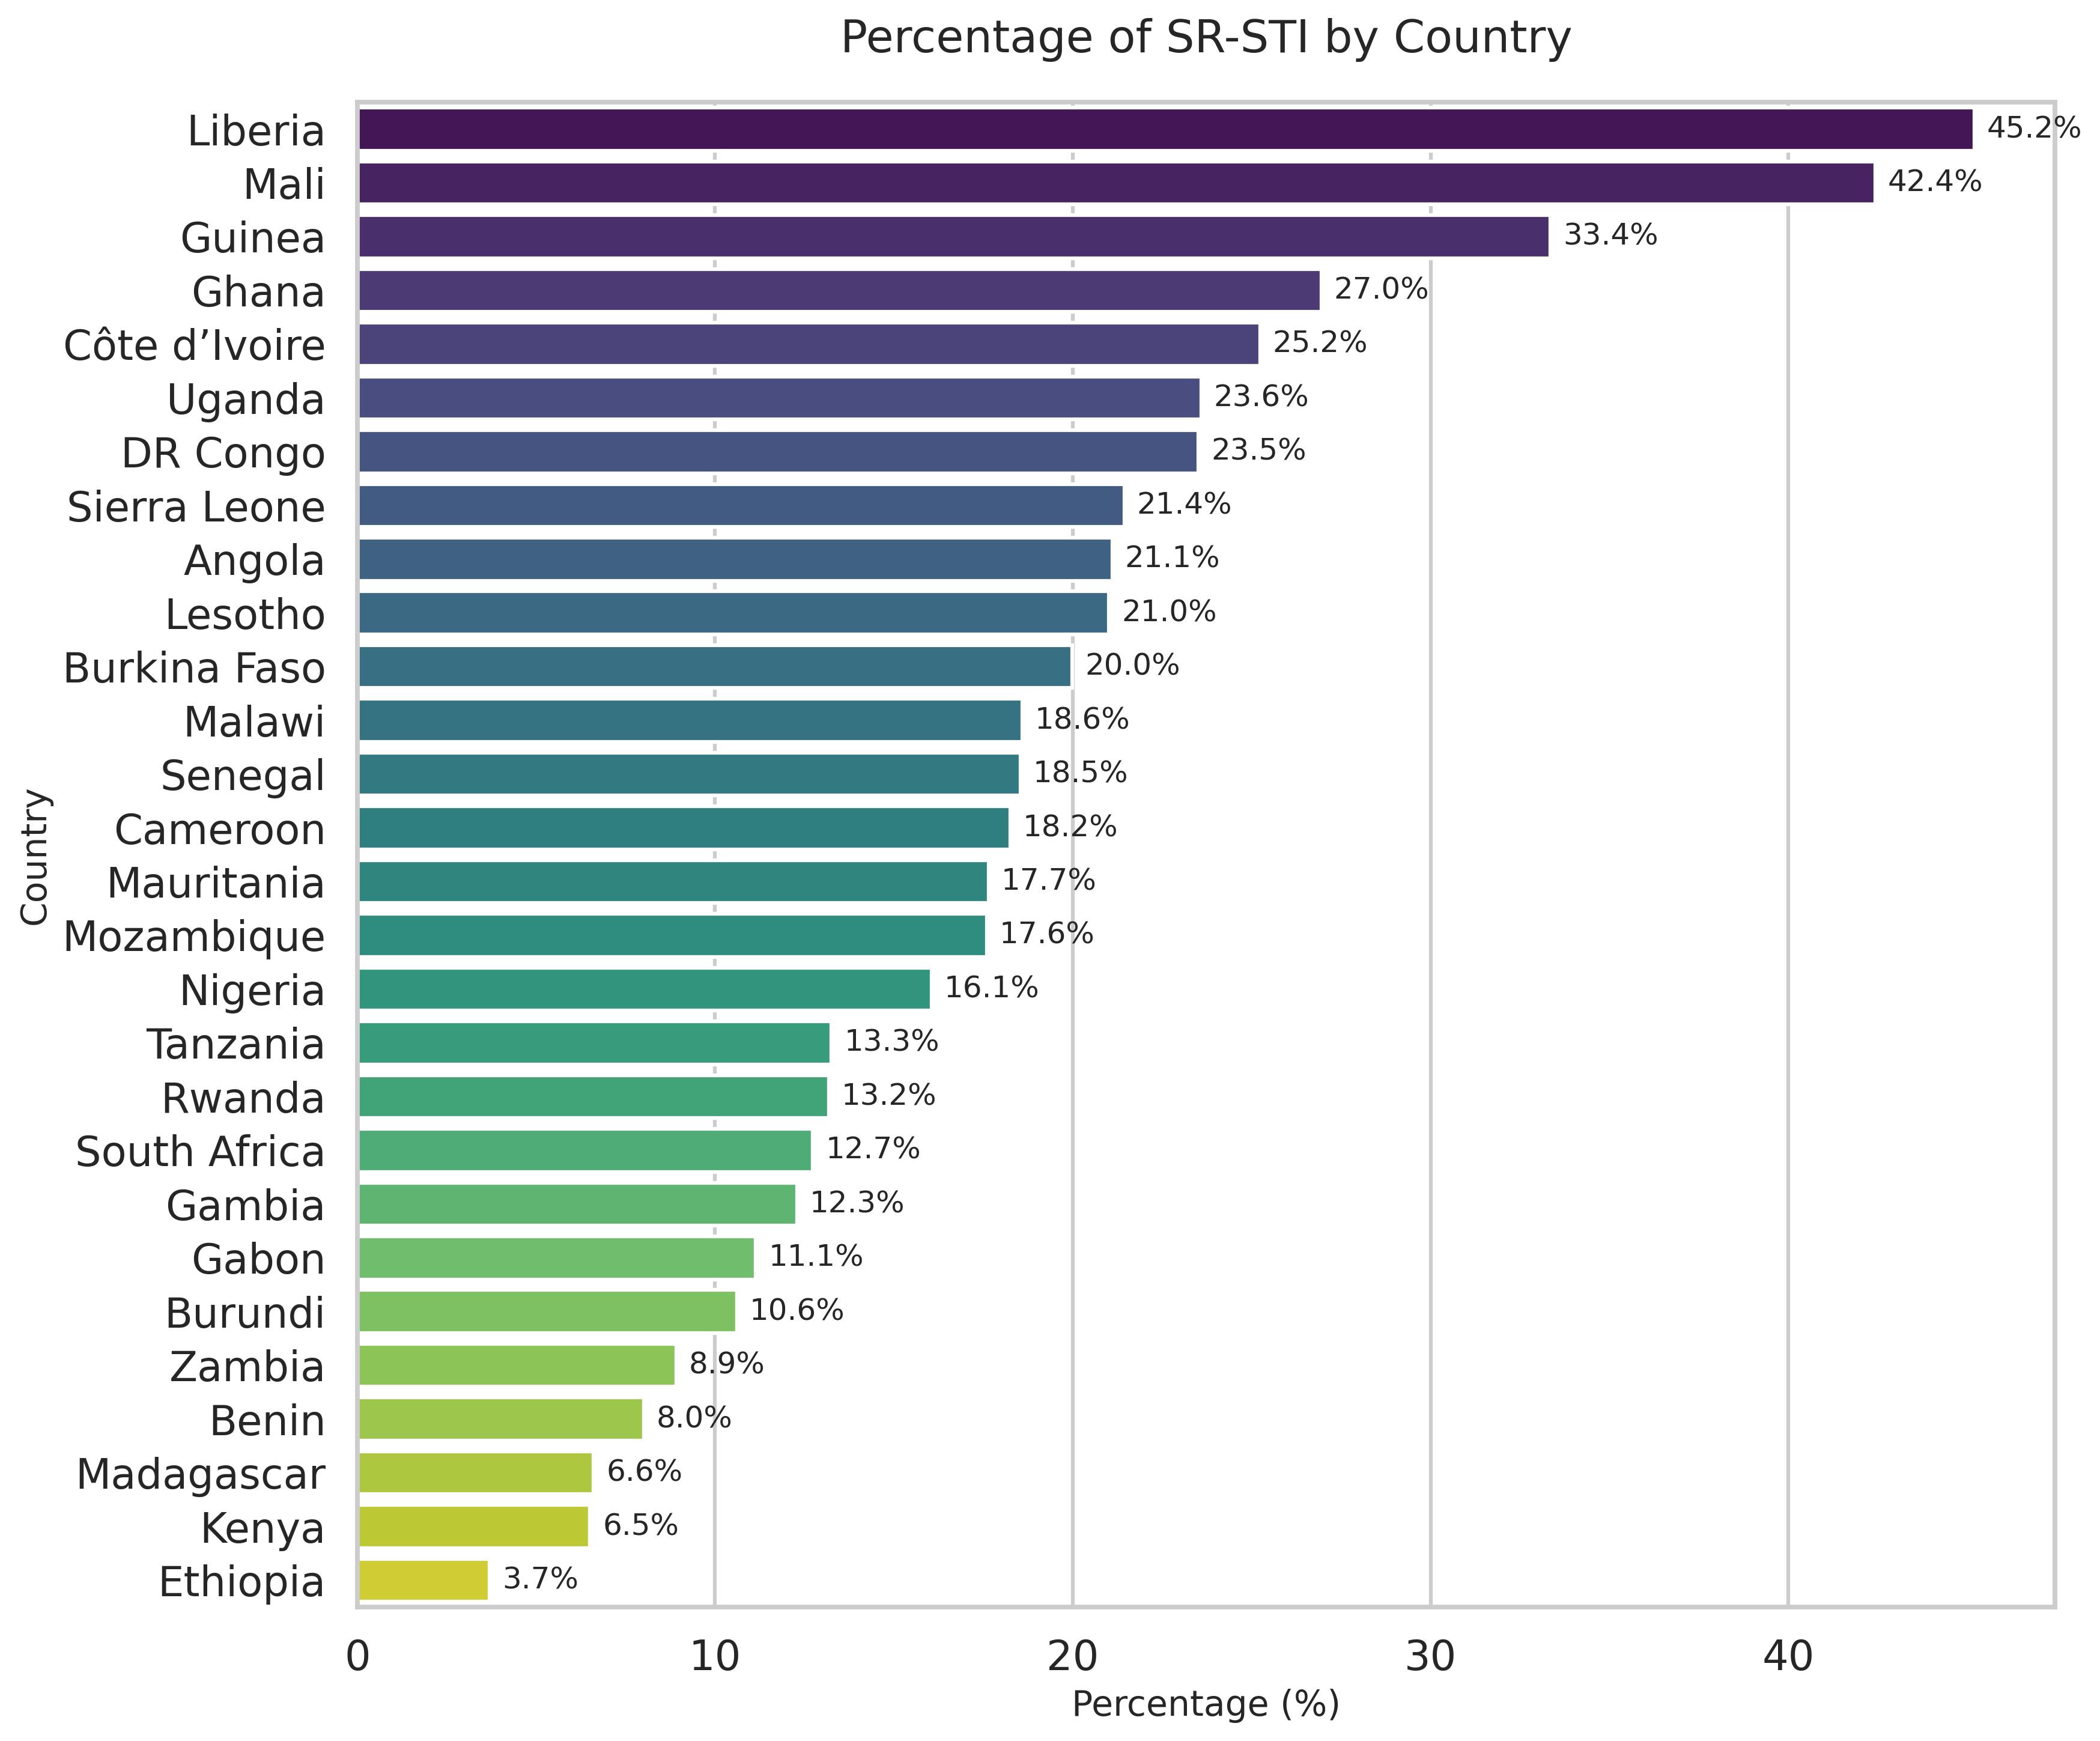

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style and context for high quality
sns.set_theme(style="whitegrid")
sns.set_context("talk")
plt.figure(figsize=(12, 10), dpi=300)

# Create the bar plot
# Note: Assigned hue='Country' to avoid the FutureWarning while keeping the palette
ax = sns.barplot(
    data=sti_by_country,
    y='Country',
    x='STI Percentage (%)',
    palette='viridis',
    hue='Country',
    legend=False
)

# Add labels and title
plt.title('Percentage of SR-STI by Country', fontsize=18, pad=20)
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('Country', fontsize=14)

# Add data labels on the bars with better formatting
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=5, fontsize=12)

plt.tight_layout()
plt.show()

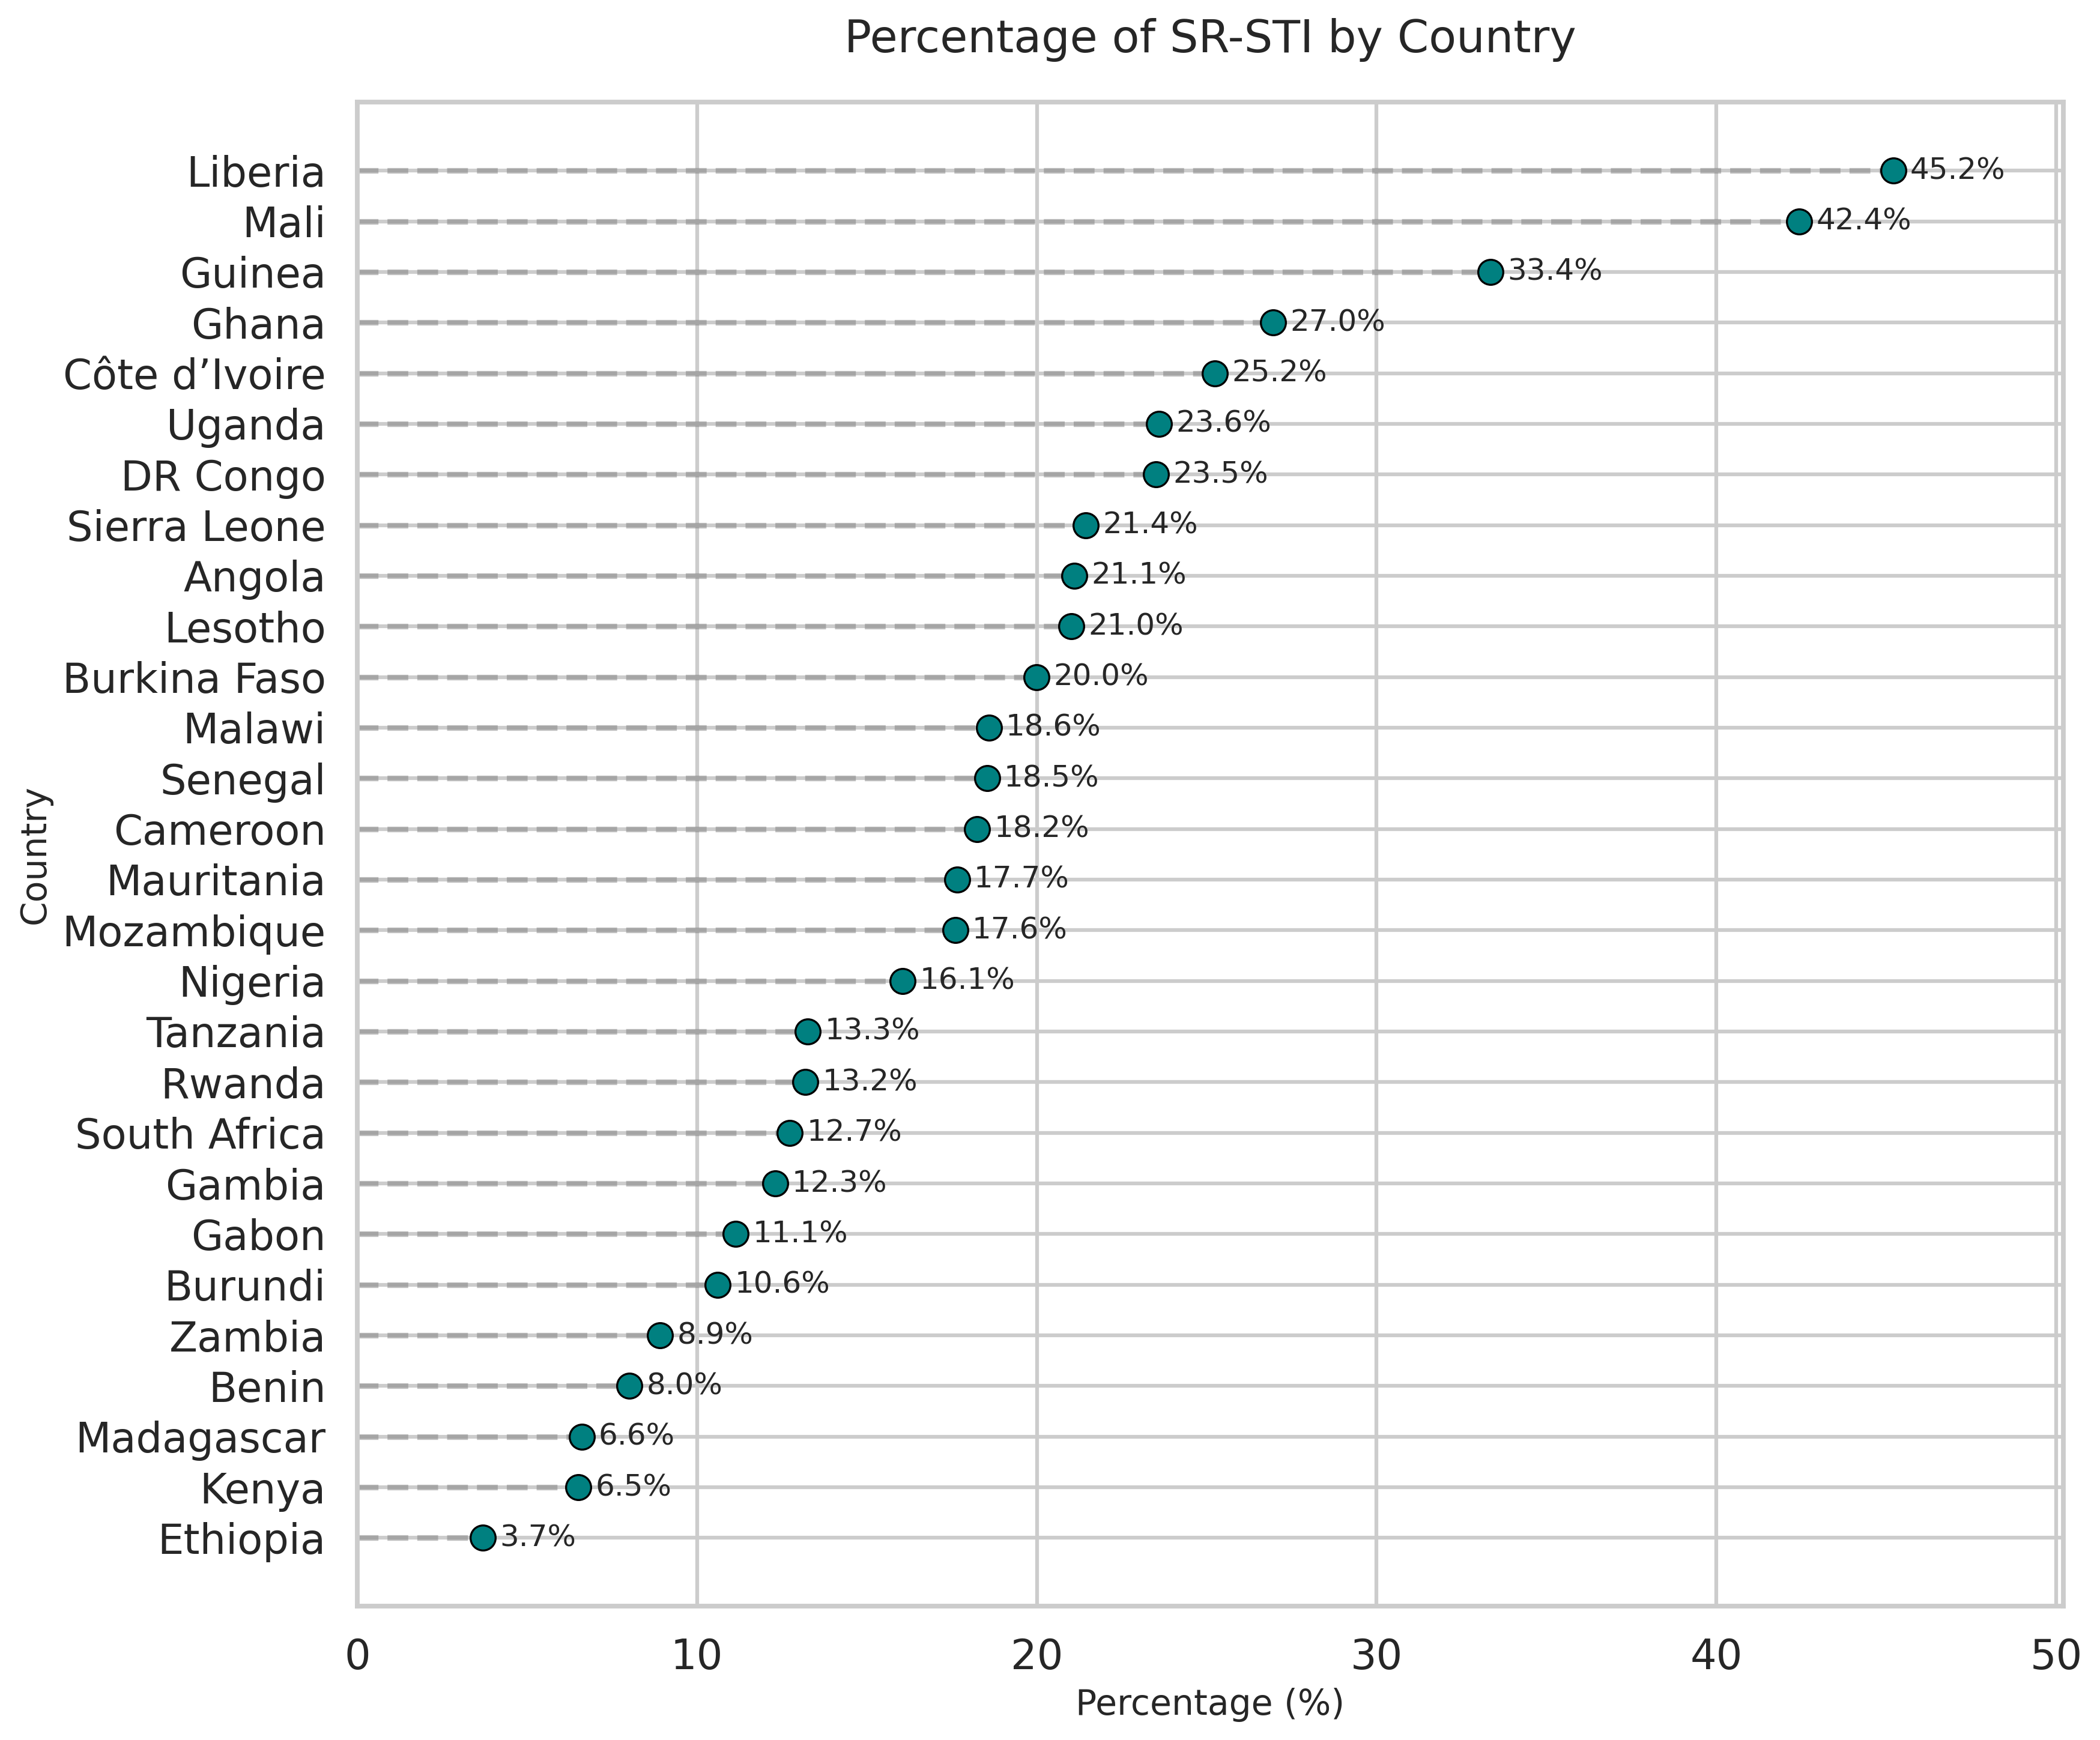

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style and context
sns.set_theme(style="whitegrid")
sns.set_context("talk")
plt.figure(figsize=(12, 10), dpi=300)

# Create the dot plot using sns.scatterplot
ax = sns.scatterplot(
    data=sti_by_country,
    x='STI Percentage (%)',
    y='Country',
    s=100,
    color='teal',
    edgecolor='black',
    zorder=3
)

# Add horizontal lines for each country to improve readability (Cleveland Dot Plot style)
plt.hlines(y=sti_by_country['Country'], xmin=0, xmax=sti_by_country['STI Percentage (%)'], color='gray', alpha=0.5, linestyles='--')

# Add labels and title
plt.title('Percentage of SR-STI by Country', fontsize=18, pad=20)
plt.xlabel('Percentage (%)', fontsize=14)
plt.ylabel('Country', fontsize=14)

# Add data labels next to the dots
for i, row in sti_by_country.iterrows():
    plt.text(row['STI Percentage (%)'] + 0.5, i, f"{row['STI Percentage (%)']:.1f}%", va='center', fontsize=12)

plt.xlim(0, sti_by_country['STI Percentage (%)'].max() + 5)
plt.tight_layout()
plt.show()

In [140]:
import plotly.express as px
import os

# Create the choropleth map using Plotly
fig = px.choropleth(
    sti_by_country,
    locations='Country',
    locationmode='country names',
    color='STI Percentage (%)',
    hover_name='Country',
    color_continuous_scale='YlOrRd',
    title='Choropleth Map of SR-STI Percentage by Country',
    labels={'STI Percentage (%)': 'Percentage (%)'},
    scope='africa'
)

# Update map layout
fig.update_layout(
    height=700,
    margin={"r":0,"t":50,"l":0,"b":0}
)

# Add text labels on the map
fig.add_scattergeo(
    locations=sti_by_country['Country'],
    locationmode='country names',
    text=sti_by_country['STI Percentage (%)'].round(1).astype(str) + '%',
    mode='text',
    showlegend=False,
    textfont=dict(size=10, color='black')
)

# Save as PNG
try:
    fig.write_image("STI_Choropleth_Map.png", scale=3, engine="kaleido")
    print("Map saved as STI_Choropleth_Map.png")
except Exception as e:
    print(f"Error saving image: {e}")
    print("Try running this cell one more time to refresh the kaleido engine.")

fig.show()

Error saving image: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Try running this cell one more time to refresh the kaleido engine.


In [141]:
!pip install -U kaleido
import kaleido
try:
    # Using scale=3 for high-resolution JPG output
    fig.write_image("STI_Choropleth_Map.jpg", scale=3, engine="kaleido")
    print("Map successfully saved as STI_Choropleth_Map.jpg")
except Exception as e:
    print(f"Error saving image: {e}")
    print("\nTroubleshooting:")
    print("1. If this is the first time installing kaleido, please restart the runtime and run this cell again.")
    print("2. Ensure the variable 'fig' exists by running the map creation cell above.")

Error saving image: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


Troubleshooting:
1. If this is the first time installing kaleido, please restart the runtime and run this cell again.
2. Ensure the variable 'fig' exists by running the map creation cell above.


In [142]:
import pandas as pd
# Show all columns without truncation
pd.set_option('display.max_columns', None)
df.head()

,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,contraceptive_method,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,0,no,Southern Africa,0,0
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,1,no,Southern Africa,0,0
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,15,not working,no,no,no,1,yes,Southern Africa,0,0
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,11,not working,no,no,no,1,no,Southern Africa,0,0
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,no,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa,0,0


In [144]:
import pandas as pd

# Define bins and labels for Maternal_age
bins = [14, 24, 34, 49]
labels = ['15-24', '25-34', '35-49']

# Create the Age_group column
df['maternal_Age_group'] = pd.cut(df['Maternal_age'], bins=bins, labels=labels)

# Display the value counts to verify the categorization
print("Frequency distribution of Age Groups:")
print(df['maternal_Age_group'].value_counts())

# Show the first few rows
df.head()

Frequency distribution of Age Groups:
maternal_Age_group
35-49    135370
25-34    134430
15-24    118372
Name: count, dtype: int64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,contraceptive_method,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI,maternal_Age_group
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,0,no,Southern Africa,0,0,15-24
1,Angola,20,urban,primary,not at all,not at all,not at all,no,never,poorer,no,not using,no,not a big problem,no,living with partner,19,not working,no,no,no,1,no,Southern Africa,0,0,15-24
2,Angola,21,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,15,not working,no,no,no,1,yes,Southern Africa,0,0,15-24
3,Angola,19,urban,no education,not at all,not at all,not at all,no,never,poorer,no,not using,yes,not a big problem,no,living with partner,11,not working,no,no,no,1,no,Southern Africa,0,0,15-24
4,Angola,32,urban,no education,not at all,not at all,not at all,no,never,poorest,no,not using,no,not a big problem,no,no longer living together/separated,15,not working,no,no,no,1,no,Southern Africa,0,0,25-34


In [152]:
# Recategorize uses_internet into 'Yes' or 'No'
internet_map = {
    'never': 'No',
    'yes, last 12 months': 'Yes',
    'yes, before last 12 months': 'Yes'
}

df['uses_internet'] = df['uses_internet'].map(internet_map)

# Display the new value counts
print(df['uses_internet'].value_counts(dropna=False))

uses_internet
No     287555
Yes    100617
Name: count, dtype: int64


In [160]:
# Recategorize contraceptive_method into 'Yes' or 'No'
def categorize_contraception(val):
    if pd.isna(val):
        return val
    if str(val).lower() == 'not using':
        return 'No'
    return 'Yes'

# Apply categorization
df['contraceptive_method'] = df['contraceptive_method'].apply(categorize_contraception)

# Rename column to Contraceptive_use
df = df.rename(columns={'contraceptive_method': 'Contraceptive_use'})

# Display the new value counts
print(df['Contraceptive_use'].value_counts(dropna=False))

Contraceptive_use
No     267891
Yes    120281
Name: count, dtype: int64


In [167]:
# Define the mapping for marital status
marital_map = {
    'married': 'Married',
    'living with partner': 'Married',
    'never in union': 'Unmarried',
    'no longer living together/separated': 'Unmarried',
    'divorced': 'Unmarried',
    'widowed': 'Unmarried',
    '6': 'Unmarried'
}

# Apply the mapping to the marital_status column
df['marital_status'] = df['marital_status'].map(marital_map)

# Display the new value counts to verify
print("Frequency distribution of Marital Status:")
print(df['marital_status'].value_counts(dropna=False))

Frequency distribution of Marital Status:
marital_status
Married      279712
Unmarried    108460
Name: count, dtype: int64


In [168]:
df.head()

,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,Contraceptive_use,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI,maternal_Age_group
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,not working,no,no,no,0,no,Southern Africa,0,0,15-24
1,Angola,20,urban,primary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,not working,no,no,no,1,no,Southern Africa,0,0,15-24
2,Angola,21,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,15,not working,no,no,no,1,yes,Southern Africa,0,0,15-24
3,Angola,19,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,11,not working,no,no,no,1,no,Southern Africa,0,0,15-24
4,Angola,32,urban,no education,not at all,not at all,not at all,no,No,poorest,no,No,no,not a big problem,no,Unmarried,15,not working,no,no,no,1,no,Southern Africa,0,0,25-34


In [174]:
import pandas as pd
import numpy as np

# Convert to numeric to handle comparisons, coercing non-numeric to NaN
df['age_first_sex_numeric'] = pd.to_numeric(df['age_first_sex'], errors='coerce')

# Categorize into <18 and >=18
def categorize_age_first_sex(val):
    if pd.isna(val):
        return np.nan
    return '<18' if val < 18 else '>=18'

df['age_first_sex_cat'] = df['age_first_sex_numeric'].apply(categorize_age_first_sex)

# Manage missing values using mode imputation
# Identify columns with missing values
missing_cols = df.columns[df.isnull().any()]

for col in missing_cols:
    # Calculate the mode (index 0 is the most frequent)
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# Display counts and clean up
print("Counts for age_first_sex_cat after imputation:")
print(df['age_first_sex_cat'].value_counts(dropna=False))

# Verify no missing values remain
print("\nTotal missing values remaining:", df.isnull().sum().sum())

df = df.drop(columns=['age_first_sex_numeric'])
df.head()

Counts for age_first_sex_cat after imputation:
age_first_sex_cat
<18     253168
>=18    135004
Name: count, dtype: int64

Total missing values remaining: 0


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,Contraceptive_use,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI,maternal_Age_group,age_first_sex_cat
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,not working,no,no,no,0,no,Southern Africa,0,0,15-24,>=18
1,Angola,20,urban,primary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,not working,no,no,no,1,no,Southern Africa,0,0,15-24,>=18
2,Angola,21,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,15,not working,no,no,no,1,yes,Southern Africa,0,0,15-24,<18
3,Angola,19,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,11,not working,no,no,no,1,no,Southern Africa,0,0,15-24,<18
4,Angola,32,urban,no education,not at all,not at all,not at all,no,No,poorest,no,No,no,not a big problem,no,Unmarried,15,not working,no,no,no,1,no,Southern Africa,0,0,25-34,<18


In [176]:
# Recategorize Occupation_status into Working and Not working
def categorize_occupation(val):
    if pd.isna(val) or str(val).lower() in ['not working', '.a', '96', "don't know/other"]:
        return 'Not working'
    return 'Working'

# Apply categorization
df['Occupation_status'] = df['Occupation_status'].apply(categorize_occupation)

# Display the new value counts
print("Frequency distribution of Occupation Status:")
print(df['Occupation_status'].value_counts(dropna=False))

df.head()

Frequency distribution of Occupation Status:
Occupation_status
Working        247740
Not working    140432
Name: count, dtype: int64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,Contraceptive_use,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI,maternal_Age_group,age_first_sex_cat
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,Not working,no,no,no,0,no,Southern Africa,0,0,15-24,>=18
1,Angola,20,urban,primary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,Not working,no,no,no,1,no,Southern Africa,0,0,15-24,>=18
2,Angola,21,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,15,Not working,no,no,no,1,yes,Southern Africa,0,0,15-24,<18
3,Angola,19,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,11,Not working,no,no,no,1,no,Southern Africa,0,0,15-24,<18
4,Angola,32,urban,no education,not at all,not at all,not at all,no,No,poorest,no,No,no,not a big problem,no,Unmarried,15,Not working,no,no,no,1,no,Southern Africa,0,0,25-34,<18


In [179]:
# Ensure the column is numeric
df['number_sexual_partner_12months'] = pd.to_numeric(df['number_sexual_partner_12months'], errors='coerce')

# Recategorize: >= 2 as 'Yes', < 2 as 'No'
def categorize_partners(val):
    if pd.isna(val):
        return 'No'  # Or np.nan if you prefer to keep missing values separate
    return 'Yes' if val >= 2 else 'No'

df['Multiple_sexual_partners'] = df['number_sexual_partner_12months'].apply(categorize_partners)

# Display the results
print("Frequency distribution of Multiple Sexual Partners:")
print(df['Multiple_sexual_partners'].value_counts())

print("\nPercentage distribution:")
print(df['Multiple_sexual_partners'].value_counts(normalize=True) * 100)

df.head()

Frequency distribution of Multiple Sexual Partners:
Multiple_sexual_partners
No     377856
Yes     10316
Name: count, dtype: int64

Percentage distribution:
Multiple_sexual_partners
No     97.342415
Yes     2.657585
Name: proportion, dtype: float64


,country,Maternal_age,residence,education_level,reads_newspaper,listens_radio,watches_tv,owns_mobile_phone,uses_internet,wealth_index,ever_terminated_pregnancy,Contraceptive_use,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,marital_status,age_first_sex,Occupation_status,had_any_STI_in12months,genital_ulcer_in12months,genital_discharge_in12months,number_sexual_partner_12months,ever_tested_for_HIV,Geographic_region,Media_exposure,STI,maternal_Age_group,age_first_sex_cat,Multiple_sexual_partners
0,Angola,21,urban,secondary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,Not working,no,no,no,0.0,no,Southern Africa,0,0,15-24,>=18,No
1,Angola,20,urban,primary,not at all,not at all,not at all,no,No,poorer,no,No,no,not a big problem,no,Married,19,Not working,no,no,no,1.0,no,Southern Africa,0,0,15-24,>=18,No
2,Angola,21,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,15,Not working,no,no,no,1.0,yes,Southern Africa,0,0,15-24,<18,No
3,Angola,19,urban,no education,not at all,not at all,not at all,no,No,poorer,no,No,yes,not a big problem,no,Married,11,Not working,no,no,no,1.0,no,Southern Africa,0,0,15-24,<18,No
4,Angola,32,urban,no education,not at all,not at all,not at all,no,No,poorest,no,No,no,not a big problem,no,Unmarried,15,Not working,no,no,no,1.0,no,Southern Africa,0,0,25-34,<18,No


In [189]:
# Calculate mode for ever_tested_for_HIV
hiv_mode = df['ever_tested_for_HIV'].mode()[0]

# Impute missing values (including '.a' if it represents missingness)
df['ever_tested_for_HIV'] = df['ever_tested_for_HIV'].replace('.a', hiv_mode).fillna(hiv_mode)

# Verify the results
print("Frequency distribution after mode imputation:")
print(df['ever_tested_for_HIV'].value_counts(dropna=False))

Frequency distribution after mode imputation:
ever_tested_for_HIV
yes    229423
no     158749
Name: count, dtype: int64


In [190]:
df.columns

Index(['country', 'Maternal_age', 'residence', 'education_level',
       'reads_newspaper', 'listens_radio', 'watches_tv', 'owns_mobile_phone',
       'uses_internet', 'wealth_index', 'ever_terminated_pregnancy',
       'Contraceptive_use', 'visited_HF-in last12_months',
       'distance_to_health_facility', 'Health_insurance_coverage',
       'marital_status', 'age_first_sex', 'Occupation_status',
       'had_any_STI_in12months', 'genital_ulcer_in12months',
       'genital_discharge_in12months', 'number_sexual_partner_12months',
       'ever_tested_for_HIV', 'Geographic_region', 'Media_exposure', 'STI',
       'maternal_Age_group', 'age_first_sex_cat', 'Multiple_sexual_partners'],
      dtype='object')

In [191]:
# Define the list of selected columns
selected_columns = [
    'Geographic_region', 'maternal_Age_group', 'residence', 'education_level','marital_status',
     'Occupation_status','wealth_index','owns_mobile_phone', 'uses_internet', 'Media_exposure',
    'Contraceptive_use',  'ever_terminated_pregnancy','visited_HF-in last12_months',
    'distance_to_health_facility', 'Health_insurance_coverage',  'age_first_sex_cat', 'Multiple_sexual_partners',
    'ever_tested_for_HIV',  'STI'
]

# Filter the dataframe
df_final = df[selected_columns]

# Display summary
print(f"Final subset shape: {df_final.shape}")
df_final.head()

Final subset shape: (388172, 19)


,Geographic_region,maternal_Age_group,residence,education_level,marital_status,Occupation_status,wealth_index,owns_mobile_phone,uses_internet,Media_exposure,Contraceptive_use,ever_terminated_pregnancy,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,age_first_sex_cat,Multiple_sexual_partners,ever_tested_for_HIV,STI
0,Southern Africa,15-24,urban,secondary,Married,Not working,poorer,no,No,0,No,no,no,not a big problem,no,>=18,No,no,0
1,Southern Africa,15-24,urban,primary,Married,Not working,poorer,no,No,0,No,no,no,not a big problem,no,>=18,No,no,0
2,Southern Africa,15-24,urban,no education,Married,Not working,poorer,no,No,0,No,no,yes,not a big problem,no,<18,No,yes,0
3,Southern Africa,15-24,urban,no education,Married,Not working,poorer,no,No,0,No,no,yes,not a big problem,no,<18,No,no,0
4,Southern Africa,25-34,urban,no education,Unmarried,Not working,poorest,no,No,0,No,no,no,not a big problem,no,<18,No,no,0


In [192]:
import pandas as pd

# Define logical orders for ordinal variables
ordinal_orders = {
    'Geographic_region': ['West Africa', 'East Africa', 'Southern Africa', 'Central Africa'],
    'maternal_Age_group': ['15-24', '25-34', '35-49'],
    'education_level': ['no education', 'primary', 'secondary', 'higher'],
    'wealth_index': ['poorest', 'poorer', 'middle', 'richer', 'richest']
}

# List of all independent variables for the table
vars_to_analyze = [
    'Geographic_region', 'maternal_Age_group', 'residence', 'education_level',
    'marital_status', 'Occupation_status', 'wealth_index', 'owns_mobile_phone',
    'uses_internet', 'Media_exposure', 'Contraceptive_use', 'ever_terminated_pregnancy',
    'visited_HF-in last12_months', 'distance_to_health_facility',
    'Health_insurance_coverage', 'age_first_sex_cat', 'Multiple_sexual_partners',
    'ever_tested_for_HIV'
]

all_rows = []

for var in vars_to_analyze:
    # Create crosstab and percentages
    ct = pd.crosstab(df_final[var], df_final['STI'])
    ct_pct = pd.crosstab(df_final[var], df_final['STI'], normalize='index') * 100

    # Determine the order for the categories
    if var in ordinal_orders:
        # Filter order to only include existing categories
        categories = [cat for cat in ordinal_orders[var] if cat in ct.index]
        # Add any missing categories that might be in the data but not in defined order
        extra = [cat for cat in ct.index if cat not in categories]
        categories.extend(extra)
    else:
        categories = ct.index.tolist()

    # Iterate through categories of the variable in the specific order
    for i, idx in enumerate(categories):
        row = {
            'Variables': var if i == 0 else '',
            'Category': idx,
            'STI Yes N (%)': f"{ct.loc[idx, 1]} ({ct_pct.loc[idx, 1]:.1f}%)",
            'STI No N (%)': f"{ct.loc[idx, 0]} ({ct_pct.loc[idx, 0]:.1f}%)"
        }
        all_rows.append(row)

# Create final summary dataframe
summary_table_all = pd.DataFrame(all_rows)

# Save as CSV
summary_table_all.to_csv('Summary_Table_All_Variables.csv', index=False)

print("Complete summary table prepared and saved as Summary_Table_All_Variables.csv")
summary_table_all

Complete summary table prepared and saved as Summary_Table_All_Variables.csv


,Variables,Category,STI Yes N (%),STI No N (%)
0,Geographic_region,West Africa,37818 (22.4%),131018 (77.6%)
1,,East Africa,10287 (11.4%),79738 (88.6%)
2,,Southern Africa,12699 (14.8%),73350 (85.2%)
3,,Central Africa,8527 (19.7%),34735 (80.3%)
4,maternal_Age_group,15-24,22248 (18.8%),96124 (81.2%)
5,,25-34,25572 (19.0%),108858 (81.0%)
6,,35-49,21511 (15.9%),113859 (84.1%)
7,residence,rural,40846 (17.2%),196624 (82.8%)
8,,urban,28485 (18.9%),122217 (81.1%)
9,education_level,no education,21587 (17.6%),101351 (82.4%)


In [183]:
df_final['Geographic_region'].value_counts()

,count
Geographic_region,
West Africa,168836
East Africa,90025
Southern Africa,86049
Central Africa,43262


## Data Preprocessing
### Feature selection techniques

In [197]:
import pandas as pd

# Start with df_final which contains all our selected columns
df_encoded = df_final.copy()

# --------------------------------------------------
# 1. One-Hot Encoding for Geographic_region
# --------------------------------------------------
geo_dummies = pd.get_dummies(
    df_encoded["Geographic_region"],
    prefix="Region",
    drop_first=False
)

# Add encoded columns and drop the original
df_encoded = pd.concat([df_encoded, geo_dummies], axis=1)
df_encoded.drop("Geographic_region", axis=1, inplace=True)

# --------------------------------------------------
# 2. Encode Remaining Variables
# --------------------------------------------------

# Mapping dictionary for all categorical variables
mappings = {
    "maternal_Age_group": {"15-24": 1, "25-34": 2, "35-49": 3},
    "residence": {"rural": 0, "urban": 1},
    "education_level": {"no education": 0, "primary": 1, "secondary": 2, "higher": 3},
    "marital_status": {"Unmarried": 0, "Married": 1},
    "Occupation_status": {"Not working": 0, "Working": 1},
    "wealth_index": {"poorest": 1, "poorer": 2, "middle": 3, "richer": 4, "richest": 5},
    "owns_mobile_phone": {"no": 0, "yes": 1},
    "uses_internet": {"No": 0, "Yes": 1},
    "Contraceptive_use": {"No": 0, "Yes": 1},
    "ever_terminated_pregnancy": {"no": 0, "yes": 1},
    "visited_HF-in last12_months": {"no": 0, "yes": 1},
    "distance_to_health_facility": {"big problem": 1, "not a big problem": 0},
    "Health_insurance_coverage": {"no": 0, "yes": 1},
    "age_first_sex_cat": {"<18": 0, ">=18": 1},
    "Multiple_sexual_partners": {"No": 0, "Yes": 1},
    "ever_tested_for_HIV": {"no": 0, "yes": 1}
}

for col, mapping in mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)

# --------------------------------------------------
# 3. Final Conversion and Verification
# --------------------------------------------------
# Convert all columns to numeric (bools from dummies to int)
df_encoded = df_encoded.apply(pd.to_numeric, errors="ignore")

print("Encoding complete. All variables converted to numeric format.")
df_encoded.head()

Encoding complete. All variables converted to numeric format.


/tmp/ipykernel_1371/601494830.py:51: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead



,maternal_Age_group,residence,education_level,marital_status,Occupation_status,wealth_index,owns_mobile_phone,uses_internet,Media_exposure,Contraceptive_use,ever_terminated_pregnancy,visited_HF-in last12_months,distance_to_health_facility,Health_insurance_coverage,age_first_sex_cat,Multiple_sexual_partners,ever_tested_for_HIV,STI,Region_Central Africa,Region_East Africa,Region_Southern Africa,Region_West Africa
0,1,1,2,1,0,2,0,0,0,0,0,0,0,0,1,0,0,0,False,False,True,False
1,1,1,1,1,0,2,0,0,0,0,0,0,0,0,1,0,0,0,False,False,True,False
2,1,1,0,1,0,2,0,0,0,0,0,1,0,0,0,0,1,0,False,False,True,False
3,1,1,0,1,0,2,0,0,0,0,0,1,0,0,0,0,0,0,False,False,True,False
4,2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,False,False,True,False


## Split Dataset into Training and Testing

In [198]:
from sklearn.model_selection import train_test_split

# Define target (y) and features (X)
y = df_encoded['STI']
X = df_encoded.drop(columns=['STI'])

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Display the shapes of the resulting sets
print(f"Total samples: {len(df_encoded)}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nTarget distribution in Training set:")
print(y_train.value_counts(normalize=True) * 100)

Total samples: 388172
Training set shape: (310537, 21)
Testing set shape: (77635, 21)

Target distribution in Training set:
STI
0    82.139004
1    17.860996
Name: proportion, dtype: float64


## Handle Class Imbalance

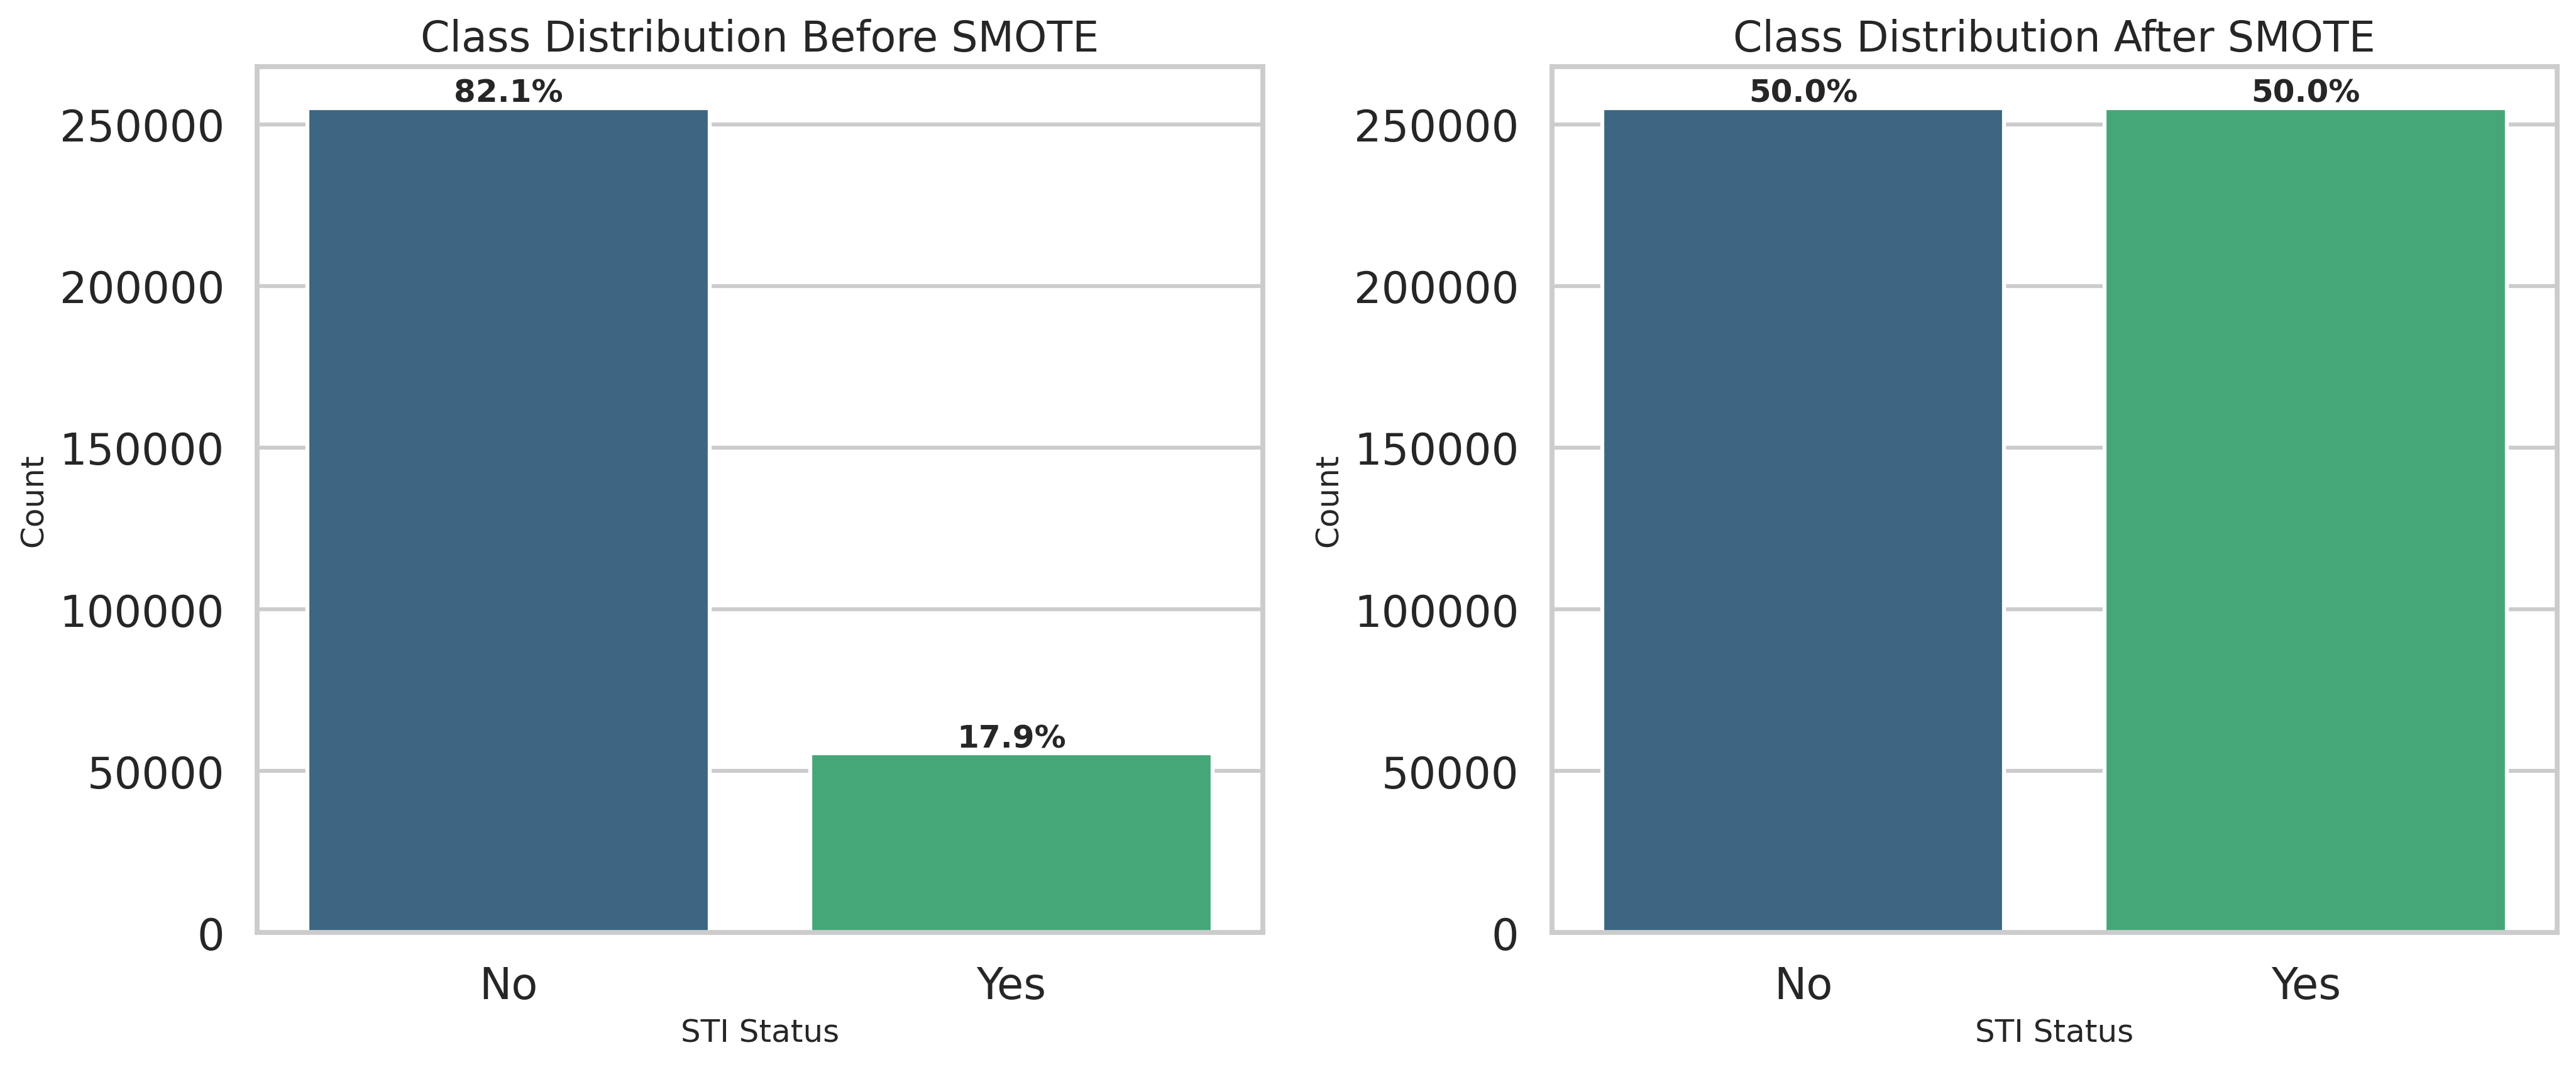

Before SMOTE: {0: 255072, 1: 55465}
After SMOTE: {0: 255072, 1: 255072}


In [200]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Perform SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Function to add percentages on top of bars
def add_percentages(ax, total):
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Visualization of class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0], hue=y_train, palette='viridis', legend=False)
axes[0].set_title('Class Distribution Before SMOTE', fontsize=16)
axes[0].set_xlabel('SR-STI Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])
add_percentages(axes[0], len(y_train))

# After SMOTE
sns.countplot(x=y_train_res, ax=axes[1], hue=y_train_res, palette='viridis', legend=False)
axes[1].set_title('Class Distribution After SMOTE', fontsize=16)
axes[1].set_xlabel('SR-STI Status', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])
add_percentages(axes[1], len(y_train_res))

plt.tight_layout()
plt.show()

# Print summary counts
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())